# Test Setup and Audio Experiment

This notebook is intended to test that all required dependencies are installed and working correctly. It will run a series of tests to ensure that the environment is properly configured for development and execution of the code.

Then, we will run a simple audio experiment to verify that the audio input and output devices are working correctly. The experiment will generate a test signal, play it through the audio output device, and record the signal through the audio input device. The recorded signal will then be analyzed to verify that it matches the original test signal.

In the process, we will discover imperfections in the analog audio channel, which we will have to mitigate if we want to succeed in transmitting and receiving digital communication signals through the audio channel.

## Test that external dependencies are installed and working correctly

A number of external dependencies are required for this course. The following tests will check that these dependencies are installed and working correctly.

In [1]:
## import modules that we will need every time
# Numpy is a fundamental package for scientific computing in Python. It provides support for arrays, matrices, and many mathematical functions.
import numpy as np

# Matplotlib is a plotting library for creating static, animated, and interactive visualizations in Python. The 'inline' magic command allows the plots to be displayed directly in the notebook.
import matplotlib.pyplot as plt
%matplotlib inline

# tweak the appearance of the plots
plt.rcParams['figure.figsize'] = (10, 6)  # Set the default figure size for plots

# seaborn is a statistical data visualization library based on Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.
import seaborn as sns
# Set the context for Seaborn plots to 'talk', which is suitable for presentations and larger text sizes.
sns_context = 'talk' 
sns.set_theme(context=sns_context, style="ticks", palette="deep")


In [2]:
## Check that the correct versions of the libraries are installed
# Check the versions of the imported libraries to ensure compatibility and reproducibility of the code.
import matplotlib as mpl
import sys
import scipy as sp
import sounddevice as sd

print("Python version:", sys.version, " (wants to be 3.10 or higher)")
print("Numpy version:", np.__version__, " (wants to be 2.5 or higher)")
print("Matplotlib version:", mpl.__version__, " (wants to be 3.11 or higher)")
print("Seaborn version:", sns.__version__, " (wants to be 0.13 or higher)")
print("Scipy version:", sp.__version__, " (wants to be 1.18 or higher)")
print("Sounddevice version:", sd.__version__, " (wants to be 0.5.6 or higher)")


Python version: 3.13.15 (main, Aug  8 2026, 17:45:26) [Clang 17.0.0 (clang-1700.3.19.1)]  (wants to be 3.10 or higher)
Numpy version: 2.5.2  (wants to be 2.5 or higher)
Matplotlib version: 3.11.1  (wants to be 3.11 or higher)
Seaborn version: 0.13.2  (wants to be 0.13 or higher)
Scipy version: 1.18.1  (wants to be 1.18 or higher)
Sounddevice version: 0.5.6  (wants to be 0.5.6 or higher)


## Test that the `dc_632_26` package loads correctly

We will gradually build up a set of modules and functions that will be used in the course. The first step is to ensure that the `dc_632_26` package loads correctly.

Initially, we will just check that the package can be imported and that the version number is available.

The code to be developed will be placed in the `src/dc_632_26` directory from where it can be imported as a package -- if your Python (virtual) environment is set up correctly.


In [3]:
## check that the `dc_632_26` package loads correctly
import dc_632_26

print(f"dc_632_26 package version {dc_632_26.__version__} loaded successfully.")

dc_632_26 package version 0.0.1 loaded successfully.


## A simple signal processing example

To illustrate the capabilities that our external dependencies provide, we will implement a simple signal processing example. This example will 

* synthesize a complex-valued, white noise signal
* apply a low-pass filter to the signal
* up-convert the signal to a "carrier frequency" to produce a real-valued pass-band signal
* plot the original, filtered, and up-converted signals in the frequency domain (PSD)

### Synthesize a complex-valued, white noise signal

In [4]:
## set signal parameters and generate a complex-valued, white noise signal
# Define the parameters for the signal processing example.
fs = 48000       # Sampling frequency in Hz
dur_s = 1.0      # Duration of the signal in seconds
f_lp = 2000      # Low-pass filter cutoff frequency in Hz
f_c = 10000      # Carrier frequency for up-conversion in Hz

pwr = 0.1        # Desired power of the synthesized signal

## synthesize a complex-valued, white noise signal
tt = np.arange(0, dur_s, 1/fs)  # Time vector from 0 to dur_s with increments of 1/fs
# Complex-valued white noise signal with desired power
ss = np.sqrt(pwr/2) * (np.random.randn(len(tt)) + 1j*np.random.randn(len(tt)))  

print(f"Generated complex-valued white noise signal with actual power {np.mean(np.abs(ss)**2):.4f} (desired {pwr})")

Generated complex-valued white noise signal with actual power 0.1002 (desired 0.1)


### Design a low-pass filter and apply it to the signal

The low-pass filter will be designed using the `scipy.signal` module. We will use an Elliptical (Cauer) IIR filter for this example. The filter will be designed using the second-order sections (SOS) representation for numerical stability.

A 16-th order filter will provide an excellent filter with a very sharp transition band.

Obviously, other filter types and orders can be used including FIR filters designed with `signal.firls`. Refer to the `scipy.signal` documentation for more information on filter design. 

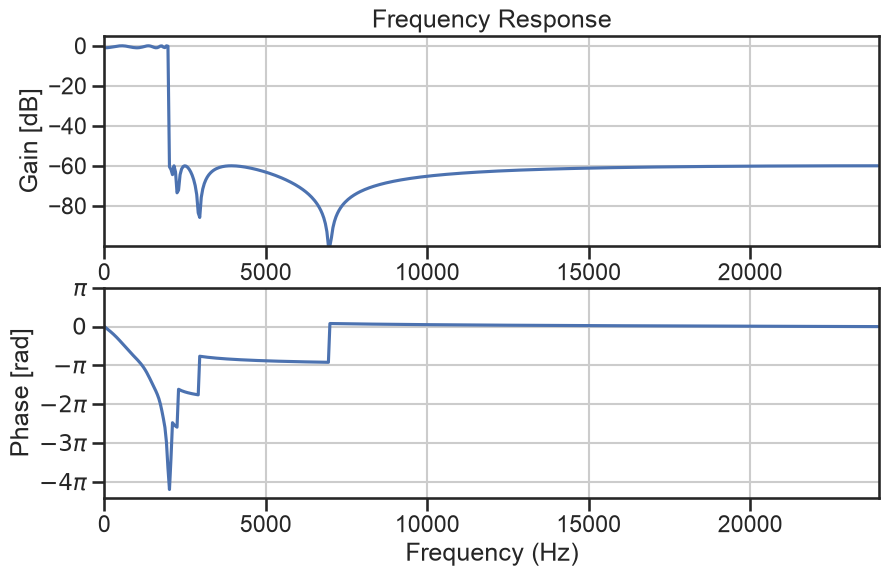

In [5]:
import scipy.signal as signal

sos = signal.ellip(16, 1, 60, f_lp, fs=fs, output='sos')
w, h = signal.freqz_sos(sos, fs=fs)

plt.subplot(2, 1, 1)
db = 20*np.log10(np.maximum(np.abs(h), 1e-5))
plt.plot(w, db)
plt.ylim(-100, 5)
plt.xlim(0, fs/2)
plt.grid(True)
plt.yticks([0, -20, -40, -60, -80])
plt.ylabel('Gain [dB]')
plt.title('Frequency Response')

plt.subplot(2, 1, 2)
phase = np.unwrap(np.angle(h))
plt.plot(w, phase)
plt.xlim(0, fs/2)
plt.grid(True)
plt.yticks([-4*np.pi, -3*np.pi, -2*np.pi, -np.pi, 0, np.pi],
           [r'$-4 \pi$', r'$-3 \pi$', r'$-2 \pi$', r'$-\pi$', r'$0$', r'$\pi$'])
plt.ylabel('Phase [rad]')
plt.xlabel('Frequency (Hz)')

plt.show()


The magnitude response is very good with excellent stop-band attenuation and a very sharp transition band. 

The phase response, however, shows a slightly non-linear phase response in the passband. This is typical of IIR filters. This means that the filter will introduce some distortion to the signal - frequency components near the cutoff frequency are delayed slightly less than components near 0. 

This is not a problem for this example, but it is something to be aware of when signal integrity is important.

We can now apply the filter to the synthesized signal and plot the results. 

Again, the `scipy.signal` module provides a number of functions for filtering signals. We will use the `sosfilt` function because we designed our filter as a cascade of second-order sections.

In [6]:
## pass the synthesized signal through the low-pass filter
ss_lp = signal.sosfilt(sos, ss)

### Up-convert the filtered signal 

To complete the example, we will up-convert the filtered signal to a "carrier frequency" to produce a real-valued pass-band signal. 

This is done by multiplying the filtered signal by a complex exponential at the desired carrier frequency and taking the real part of the result. 
$$
s_\text{pb}(t) = \sqrt{2} \cdot \text{Re}\{ s_\text{lp}(t) e^{j 2 \pi f_c t} \}.
$$
Scaling by $\sqrt{2}$ ensures that the power of the pass-band signal is equal to the power of the base-band (low-pass) signal.

The resulting signal will be a real-valued pass-band signal centered at the carrier frequency.

In [7]:
## up-convert the filtered signal to f_c
ss_pb = np.sqrt(2) * np.real(ss_lp * np.exp(1j*2*np.pi*f_c*tt))

### Spectra of signals

We plot the spectra of the original, filtered, and up-converted signals to verify that the filtering and up-conversion were successful.

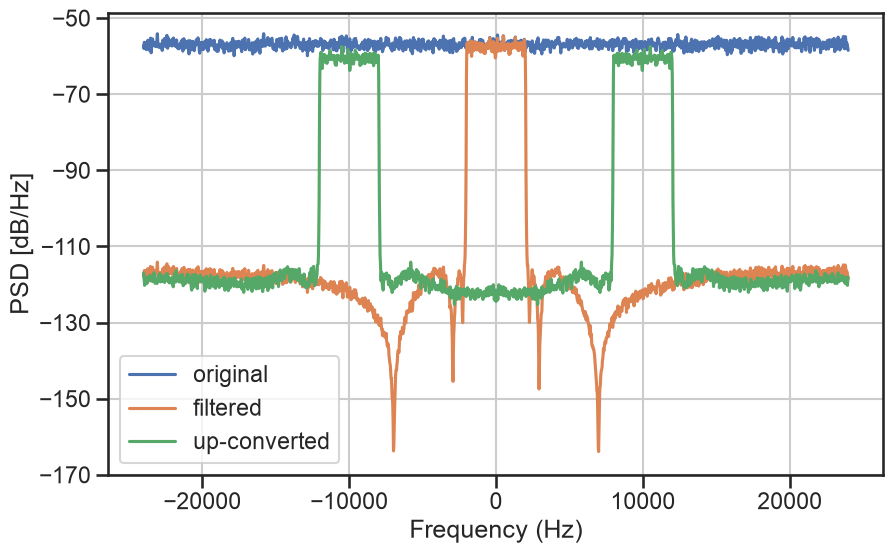

In [8]:
plt.psd(ss, Fs=fs, NFFT=2048, label='original', color='C0')
plt.psd(ss_lp, Fs=fs, NFFT=2048, label='filtered', color='C1')
plt.psd(ss_pb, Fs=fs, NFFT=2048, sides='twosided', label='up-converted', color='C2')
#plt.xlim(0, fs/2)
plt.grid(True)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD [dB/Hz]')
plt.legend()
plt.show()

## Transmitting and receiving the passband signal

To physically transmit the passband signal, we will play it through the computer's audio output. We can then receive the signal through the computer's audio input. The captured signal can then be processed with the goal to recover the original base-band signal.

Throughout this course, we will be using the `sounddevice` module to play and record audio signals. This module provides a simple interface to the computer's audio input and output devices.

We imported the `sounddevice` module earlier (as `sd`). This module provides the `sd.play` and `sd.rec` functions to play and record audio signals, respectively. It also provides the very convenient `sd.playrec` function to play and record audio signals simultaneously - exactly what we need for this example. Later in the course, we will use the `sd.InputStream` and `sd.OutputStream` classes to enable real-time processing for transmission and reception.

Let's begin by querying the available audio devices on the computer. The `sd.query_devices()` function will return a list of available audio devices. The default input and output devices are marked and can be set using the `sd.default.device` attribute. The default devices will be used by the `sd.play`, `sd.rec`, and `sd.playrec` functions.

In [9]:
## Display available audio devices - this will vary depending on the computer and operating system. The default input and output devices are marked (with `>` and `<`). You can set the default devices using `sd.default.device`. The default devices will be used by the `sd.play`, `sd.rec`, and `sd.playrec` functions.
sd.query_devices()

> 0 MacBook Pro Microphone, Core Audio (1 in, 0 out)
< 1 MacBook Pro Speakers, Core Audio (0 in, 2 out)
  2 Microsoft Teams Audio, Core Audio (1 in, 1 out)
  3 Multi-Output Device, Core Audio (0 in, 2 out)

In [10]:
## play and record the passband signal
ss_rx = sd.playrec(ss_pb, samplerate=fs, channels=1, dtype='float32')
sd.wait()  # Wait until the playback and recording are finished

# the result has shape (N, 1), i.e., two dimensions - we want a 1D array
ss_rx = ss_rx.flatten()

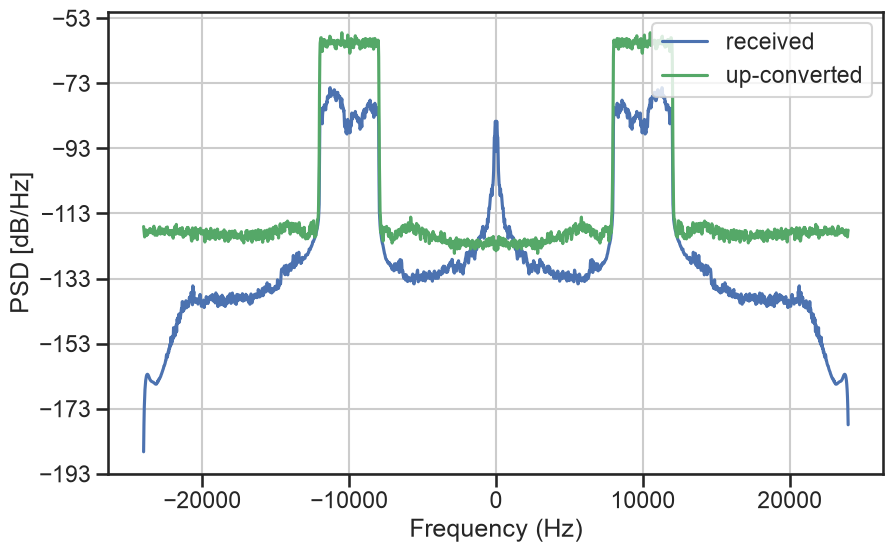

In [11]:
plt.psd(ss_rx, Fs=fs, NFFT=2048, sides='twosided', label='received', color='C0')
plt.psd(ss_pb, Fs=fs, NFFT=2048, sides='twosided', label='up-converted', color='C2')
#plt.xlim(0, fs/2)
plt.grid(True)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD [dB/Hz]')
plt.legend(loc='upper right')
plt.show()

The spectrum of the received signal clearly shows the passband signal centered at the carrier frequency. However, there are also several imperfections:

* usually, there will be strong low-frequency components in the received signal -often at 60Hz - due to rotating machinery like AC fans or motors. We will suppress these components with a filter.
* near the band-edges, the effect of an anti-alias filter can be seen.
* the spectrum of the received passband signal may not be as "flat" as the transmitted signal. This is due to the frequency response of the audio input and output devices or the acoustics of the room. 
* You may also see signs of non-linear distortion in the received signal. This is due to the non-linearities of the audio input and output devices. The non-linearities can be reduced by reducing the volume of the transmitted signal.
* Finally, there will be a noise floor in the received signal. You may have to reduce the volume of the transmitted signal to see the noise floor. 

## Can we recover the original base-band signal from the received passband signal?

To recover the original base-band signal from the received passband signal, we will need to perform the following steps:

* down-convert the received passband signal to base-band
* apply a low-pass filter to the down-converted signal to remove any high-frequency components that may have been introduced during the down-conversion process
* compare the recovered base-band signal to the original base-band signal to see how well we were able to recover it

### Down-convert and filter the received passband signal

To down-convert the received passband signal to base-band, we will multiply the received signal by a complex exponential at the negative carrier frequency. We will **not** take the real part of the result because we want to preserve the complex-valued base-band signal.

This is equivalent to using a quadrature mixer to recover the **in-phase** (I) and **quadrature** (Q) components of the base-band signal.

Filtering the down-converted signal with the same low-pass filter that we used to filter the original base-band signal will suppress any high-frequency components that may have been introduced during the down-conversion process.

In [12]:
## down-convert the received passband signal to base-band and filter it
ss_rx_bb = np.sqrt(2) *ss_rx * np.exp(-1j*2*np.pi*f_c*tt)  # Down-convert the received signal to base-band
ss_rx_bb_filt = signal.sosfilt(sos, ss_rx_bb)  # Apply the low-pass filter to the down-converted signal

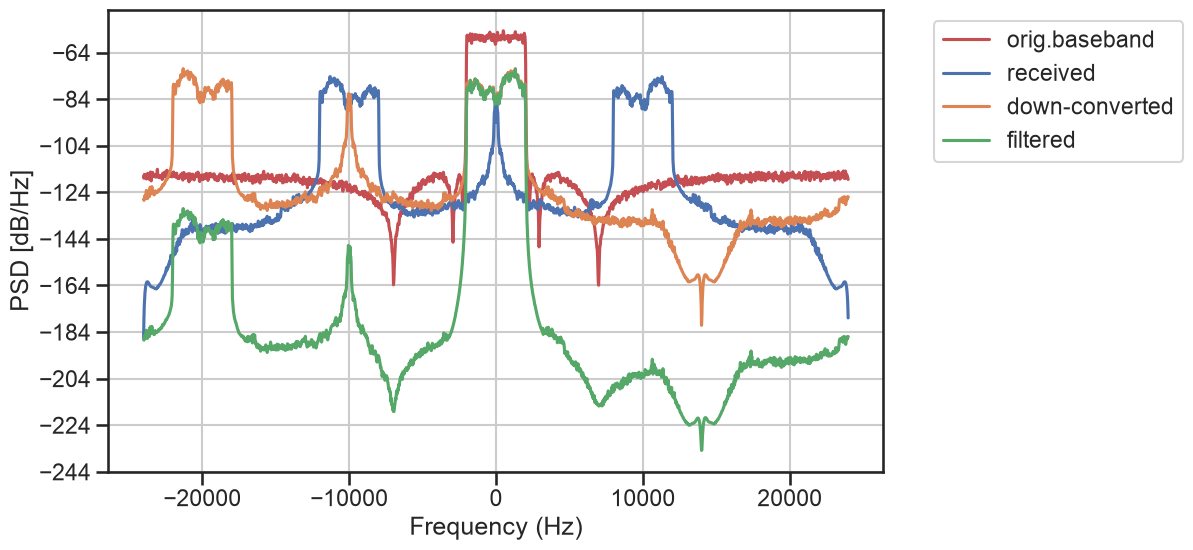

In [13]:
plt.psd(ss_lp, Fs=fs, NFFT=2048, sides='twosided', label='orig.baseband', color='C3')
plt.psd(ss_rx, Fs=fs, NFFT=2048, sides='twosided', label='received', color='C0')
plt.psd(ss_rx_bb, Fs=fs, NFFT=2048, sides='twosided', label='down-converted', color='C1')
plt.psd(ss_rx_bb_filt, Fs=fs, NFFT=2048, sides='twosided', label='filtered', color='C2')

#plt.xlim(0, fs/2)
plt.grid(True)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD [dB/Hz]')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Question:** How well were we able to recover the original base-band signal from the received passband signal?

To measure the similarity between the original base-band signal and the recovered base-band signal, we will compute the cross-correlation between the two signals. The cross-correlation will give us a measure of how similar the two signals are, and the lag at which the maximum correlation occurs will tell us how much delay was introduced during the transmission and reception process.

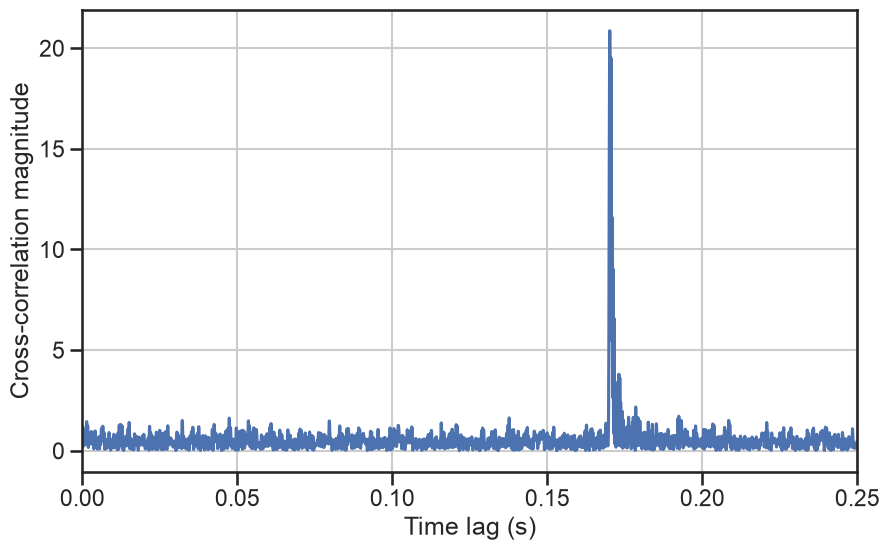

In [14]:
## compute and plot the cross-correlation between the original base-band signal and the recovered base-band signal
xcorr = signal.correlate(ss_rx_bb_filt, ss_lp, mode='full', method='fft')
lag = np.arange(-len(ss_lp) + 1, len(ss_rx_bb_filt))

plt.plot(lag/fs, np.abs(xcorr))
plt.xlabel('Time lag (s)')
plt.xlim(0, 0.25)
#plt.xlim(0.17, 0.18)
plt.ylabel('Cross-correlation magnitude')
plt.grid(True)
plt.show()

There is a strong correlation peak - but it occurs at a significant lag. That must mean that there the received signal is delayed.

Let's plot the magnitude of the recovered base-band signal to see if we can observe that delay.

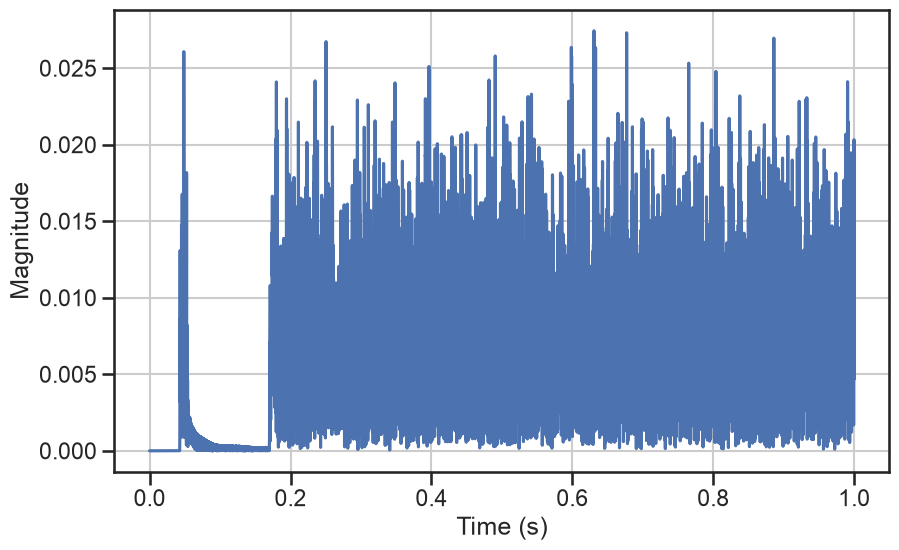

In [15]:
## plot the magnitude of the recovered base-band signal
plt.plot(tt, np.abs(ss_rx_bb_filt))
plt.xlabel('Time (s)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

Sure enough, there is a delay in the recovered base-band signal that corresponds to the lag at which the maximum correlation occurs. This delay must be induced by the sound processing, either in the `sd` module or more likely in the audio input and output devices. 

This delay is something that we will need to account for in our signal processing algorithms. We will discuss how to do this in later lectures.

Let's zoom in on the correlation peak.

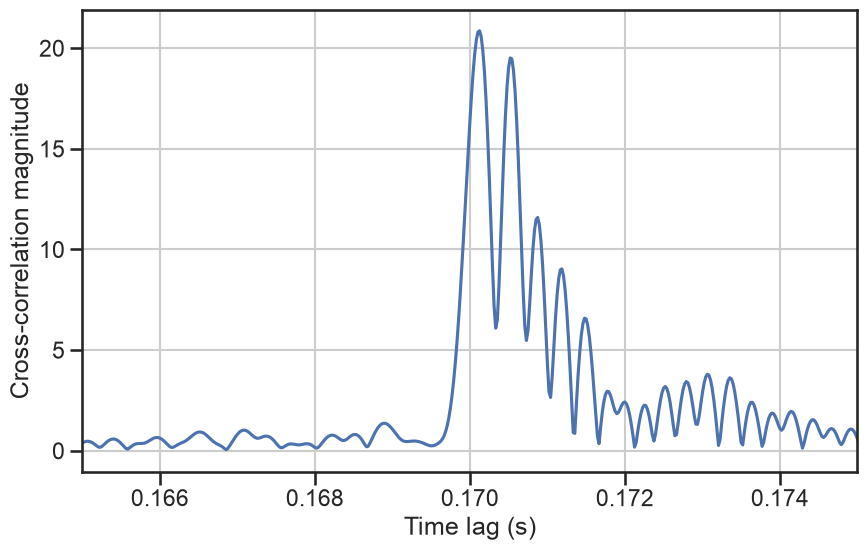

In [19]:
plt.plot(lag/fs, np.abs(xcorr))
plt.xlabel('Time lag (s)')

plt.xlim(0.165, 0.175)
plt.ylabel('Cross-correlation magnitude')
plt.grid(True)
plt.show()

Ideally, the cross-correlation would be a delayed and scaled version of the auto-correlation of the original base-band signal. This would correspond to a **distortionless** channel. 

Let's plot the auto-correlation of the original base-band signal to see how it compares to the cross-correlation of the original and recovered base-band signals.

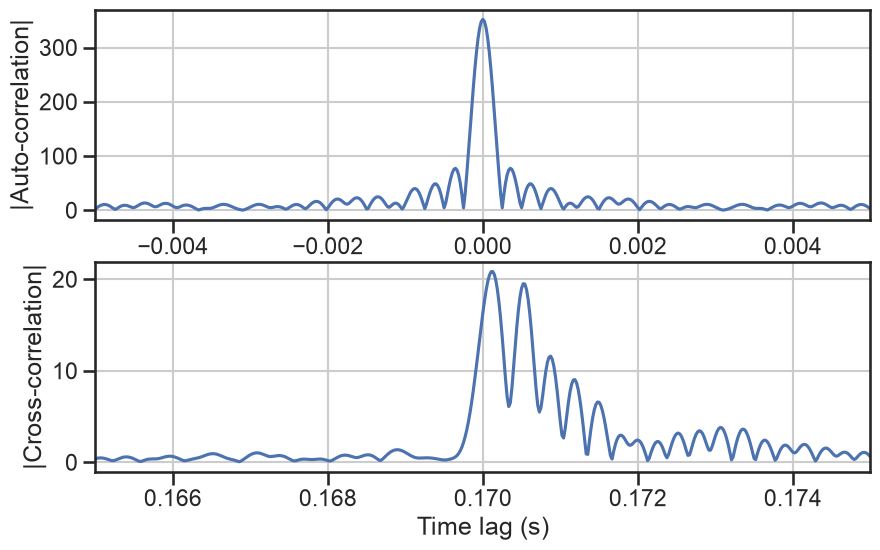

In [20]:
acorr = signal.correlate(ss_lp, ss_lp, mode='full', method='fft')
lag = np.arange(-len(ss_lp) + 1, len(ss_lp))

plt.subplot(2, 1, 1)
plt.plot(lag/fs, np.abs(acorr))
plt.xlabel('Time lag (s)')
plt.xlim(-0.005, 0.005)
plt.ylabel('|Auto-correlation|')
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(lag/fs, np.abs(xcorr))
plt.xlabel('Time lag (s)')
plt.xlim(0.165, 0.175)
plt.ylabel('|Cross-correlation|')
plt.grid(True)
plt.show()

Clearly, the cross-correlation is not just a delayed and scaled version of the auto-correlation. This indicates that the channel is not distortionless.

The cross-correlation decays more slowly than the auto-correlation. This indicates that the channel is **dispersive**. Most likely this is due to room acoustics introducing multipath propagation. The received signal is a superposition of the transmitted signal and several delayed and attenuated copies (echoes) of the transmitted signal. This is a common phenomenon in wireless communications, but it can also occur in audio communications due to reflections from walls, ceilings, and other objects in the room.

**Q:** What determines the shape of the auto-correlation function?

**A:** The shape of the auto-correlation function is determined by the filter that was used to generate the original base-band signal. Since the original signal was white noise, the auto-correlation function of the original signal is a delta function. 

And, the auto-correlation function of the filtered signal is the convolution of the filter's impulse response with (a time-reversed version of) itself.

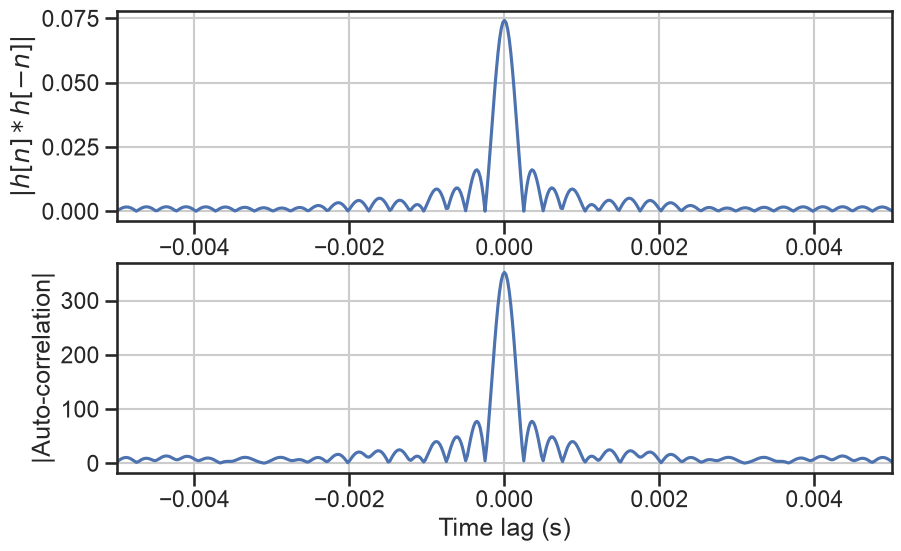

In [21]:
hh = signal.sosfilt(sos, np.concatenate(([1], np.zeros(9999))))  # Impulse response of the low-pass filter
R_hh = np.convolve(hh, hh[::-1], mode='full')  # Compute the auto-correlation of the impulse response
lag_h = np.arange(-len(hh) + 1, len(hh))

plt.subplot(2, 1, 1)
plt.plot(lag_h/fs, np.abs(R_hh))
plt.xlabel('Time lag (s)')
plt.xlim(-0.005, 0.005)
plt.ylabel('$|h[n] * h[-n]|$')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(lag/fs, np.abs(acorr))
plt.xlabel('Time lag (s)')
plt.xlim(-0.005, 0.005)
plt.ylabel('|Auto-correlation|')
plt.grid(True)
plt.show()

## Summary

This notebook provides tests to ensure that the required dependencies are installed and working correctly. 

It also provides a simple audio experiment to verify that the audio input and output devices are working correctly. The experiment generates a test signal, plays it through the audio output device, and records the signal through the audio input device. The recorded signal is then analyzed to verify that it resembles the original test signal.

In the process, we discovered imperfections in the analog audio channel, which we will have to mitigate if we want to succeed in transmitting and receiving digital communication signals through the audio channel.